# Plot 4 — Standardisation parameter plot

Summary figure: median and 68% credible intervals for **α**, **β**, and **γ** from Plots 1, 2, and 3 only shows that standardisation parameters are stable across wCDM (6 param), CPL no CMB (7 param), and CPL with CMB (7 param).

## 1. Data from Plots 1–3 (68% C.I. median +err_hi -err_lo)

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Plot 1 — wCDM 6 parameters (all flat priors)
plt1 = {
    "label": "Plot 1: wCDM 6 param",
    "alpha": (0.1687, 0.0040, 0.0042),   # median, +high err, -low err
    "beta":  (3.1200, 0.0558, 0.0556),
    "gamma": (-0.0384, 0.0089, 0.0073),
}

# Plot 2 — CPL 7 parameters (no CMB)
plt2 = {
    "label": "Plot 2: CPL 7 param (no CMB)",
    "alpha": (0.1687, 0.0040, 0.0040),
    "beta":  (3.1193, 0.0553, 0.0553),
    "gamma": (-0.0386, 0.0092, 0.0073),
}

# Plot 3 — CPL 7 parameters (with CMB)
plt3 = {
    "label": "Plot 3: CPL 7 param (with CMB)",
    "alpha": (0.1688, 0.0041, 0.0041),
    "beta":  (3.1220, 0.0557, 0.0558),
    "gamma": (-0.0390, 0.0090, 0.0071),
}

runs = [plt1, plt2, plt3]
params = ["alpha", "beta", "gamma"]

## 2. Stability comparison figure (three parameters, three models, error bars)

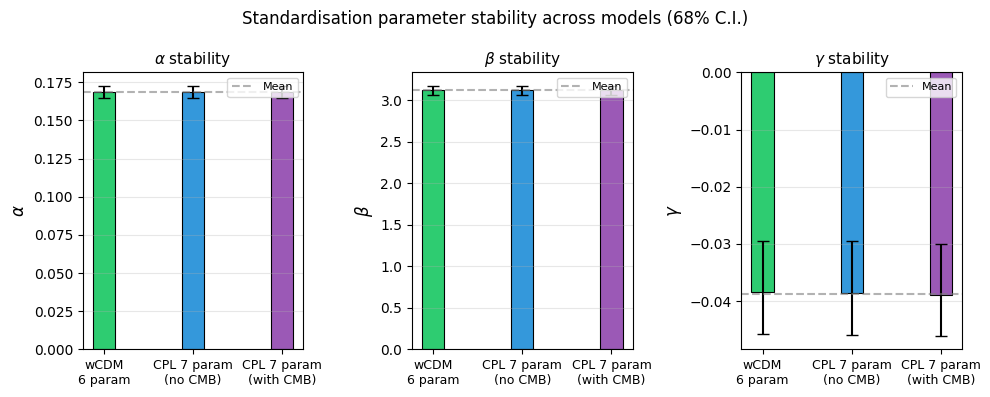

In [9]:
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=False)

x = np.arange(3)  # three models
width = 0.25

colors = ["#2ecc71", "#3498db", "#9b59b6"]
param_labels = [r"$\alpha$", r"$\beta$", r"$\gamma$"]
model_labels = [r["label"].replace("Plot 1: ", "").replace("Plot 2: ", "").replace("Plot 3: ", "") for r in runs]

for i, (ax, pname) in enumerate(zip(axes, params)):
    medians = [r[pname][0] for r in runs]
    err_hi  = [r[pname][1] for r in runs]
    err_lo  = [r[pname][2] for r in runs]
    
    yerr_asym = np.array([err_lo, err_hi])
    bars = ax.bar(x, medians, width, yerr=yerr_asym, capsize=4,
                  color=colors, edgecolor="black", linewidth=0.8, error_kw={"elinewidth": 1.5})
    ax.set_xticks(x)
    ax.set_xticklabels(["wCDM\n6 param", "CPL 7 param\n(no CMB)", "CPL 7 param\n(with CMB)"], fontsize=9)
    ax.set_ylabel(param_labels[i], fontsize=12)
    ax.set_title(param_labels[i] + " stability", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(np.mean(medians), color="gray", ls="--", alpha=0.6, label="Mean")
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Standardisation parameter stability across models (68% C.I.)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Summary table

In [11]:
import pandas as pd

rows = []
for r in runs:
    for p in params:
        m, hi, lo = r[p]
        rows.append({
            "Model": r["label"],
            "Param": p,
            "Median": m,
            "+68%": hi,
            "-68%": lo,
            "C.I.": f"{m:.4f} +{hi:.4f} -{lo:.4f}",
        })
df = pd.DataFrame(rows)
print("Standardisation parameters (median and 68% credible intervals):")
display(df)

Standardisation parameters (median and 68% credible intervals):


,Model,Param,Median,+68%,-68%,C.I.
0,Plot 1: wCDM 6 param,alpha,0.1687,0.0040,0.0042,0.1687 +0.0040 -0.0042
1,Plot 1: wCDM 6 param,beta,3.1200,0.0558,0.0556,3.1200 +0.0558 -0.0556
2,Plot 1: wCDM 6 param,gamma,-0.0384,0.0089,0.0073,-0.0384 +0.0089 -0.0073
3,Plot 2: CPL 7 param (no CMB),alpha,0.1687,0.0040,0.0040,0.1687 +0.0040 -0.0040
4,Plot 2: CPL 7 param (no CMB),beta,3.1193,0.0553,0.0553,3.1193 +0.0553 -0.0553
5,Plot 2: CPL 7 param (no CMB),gamma,-0.0386,0.0092,0.0073,-0.0386 +0.0092 -0.0073
6,Plot 3: CPL 7 param (with CMB),alpha,0.1688,0.0041,0.0041,0.1688 +0.0041 -0.0041
7,Plot 3: CPL 7 param (with CMB),beta,3.1220,0.0557,0.0558,3.1220 +0.0557 -0.0558
8,Plot 3: CPL 7 param (with CMB),gamma,-0.0390,0.0090,0.0071,-0.0390 +0.0090 -0.0071
